In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

In [3]:
print(df.columns)

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'adjclose', 'volume',
       'ticker'],
      dtype='object')


In [4]:
df = df.reset_index()

print(df.columns)

Index(['index', 'Unnamed: 0', 'open', 'high', 'low', 'close', 'adjclose',
       'volume', 'ticker'],
      dtype='object')


In [6]:
print(df.columns)

Index(['index', 'Unnamed: 0', 'open', 'high', 'low', 'close', 'adjclose',
       'volume', 'ticker'],
      dtype='object')


In [7]:
print(df.head())
print(df.columns)

df = df.reset_index()

print(df.columns)

   index  Unnamed: 0      open      high       low     close  adjclose  \
0      0  1996-01-01  2.367385  2.362865  2.360354  2.362865  1.383404   
1      1  1996-01-02  2.362865  2.380442  2.287534  2.290045  1.340769   
2      2  1996-01-03  2.290045  2.350310  2.310133  2.310133  1.352531   
3      3  1996-01-04  2.259913  2.300089  2.249869  2.249869  1.317247   
4      4  1996-01-05  2.249869  2.219737  2.209693  2.210195  1.294019   

     volume         ticker  
0   44802.0  KARURVYSYA.NS  
1  129429.0  KARURVYSYA.NS  
2   94583.0  KARURVYSYA.NS  
3   49780.0  KARURVYSYA.NS  
4   49780.0  KARURVYSYA.NS  
Index(['index', 'Unnamed: 0', 'open', 'high', 'low', 'close', 'adjclose',
       'volume', 'ticker'],
      dtype='object')
Index(['level_0', 'index', 'Unnamed: 0', 'open', 'high', 'low', 'close',
       'adjclose', 'volume', 'ticker'],
      dtype='object')


In [8]:
# Unwanted columns-ஐ நீக்குதல்
df = df.drop(columns=['level_0', 'index'], errors='ignore')

# Unnamed: 0-ஐ Date என்று மாற்றுதல்
df = df.rename(columns={'Unnamed: 0': 'Date'})

# Date column-ஐ datetime ஆக மாற்றுதல்
df['Date'] = pd.to_datetime(df['Date'])

# DataFrame-ஐ பார்க்க
print(df.head())
print(df.columns)

        Date      open      high       low     close  adjclose    volume  \
0 1996-01-01  2.367385  2.362865  2.360354  2.362865  1.383404   44802.0   
1 1996-01-02  2.362865  2.380442  2.287534  2.290045  1.340769  129429.0   
2 1996-01-03  2.290045  2.350310  2.310133  2.310133  1.352531   94583.0   
3 1996-01-04  2.259913  2.300089  2.249869  2.249869  1.317247   49780.0   
4 1996-01-05  2.249869  2.219737  2.209693  2.210195  1.294019   49780.0   

          ticker  
0  KARURVYSYA.NS  
1  KARURVYSYA.NS  
2  KARURVYSYA.NS  
3  KARURVYSYA.NS  
4  KARURVYSYA.NS  
Index(['Date', 'open', 'high', 'low', 'close', 'adjclose', 'volume', 'ticker'], dtype='object')


In [9]:
# Date-ஐ index ஆக அமைத்தல்
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

# High Price series
price_series = df['high'].dropna()

print(price_series.head())
print(price_series.tail())
print("Number of observations:", len(price_series))

Date
1996-01-01    2.362865
1996-01-02    2.380442
1996-01-03    2.350310
1996-01-04    2.300089
1996-01-05    2.219737
Name: high, dtype: float64
Date
2024-04-24    193.449997
2024-04-25    192.850006
2024-04-26    193.699997
2024-04-29    197.699997
2024-04-30    209.300003
Name: high, dtype: float64
Number of observations: 7115


In [11]:
# 80% Training, 20% Testing
train_size = int(len(price_series) * 0.8)

train = price_series[:train_size]
test = price_series[train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))
print("\nTraining data:")
print(train.head())

print("\nTesting data:")
print(test.head())




Training data: 5692
Testing data: 1423

Training data:
Date
1996-01-01    2.362865
1996-01-02    2.380442
1996-01-03    2.350310
1996-01-04    2.300089
1996-01-05    2.219737
Name: high, dtype: float64

Testing data:
Date
2018-07-20    90.090912
2018-07-23    90.181816
2018-07-24    91.136360
2018-07-25    91.545456
2018-07-26    90.909088
Name: high, dtype: float64


In [12]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,1,1) model
model_111 = ARIMA(train, order=(1, 1, 1))
model_111_fit = model_111.fit()

print(model_111_fit.summary())

C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   high   No. Observations:                 5692
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -11025.820
Date:                Tue, 08 Sep 2026   AIC                          22057.641
Time:                        04:31:05   BIC                          22077.581
Sample:                             0   HQIC                         22064.584
                               - 5692                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0437      0.004      9.753      0.000       0.035       0.053
ma.L1         -0.4562      0.005    -99.288      0.000      -0.465      -0.447
sigma2         2.8205      0.002   1186.840      0.0

In [13]:
model_011 = ARIMA(train, order=(0, 1, 1))
model_011_fit = model_011.fit()

print(model_011_fit.summary())

C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
C:\Users\GOD\Anaconda3\envs\timeseries\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   high   No. Observations:                 5692
Model:                 ARIMA(0, 1, 1)   Log Likelihood              -11026.797
Date:                Tue, 08 Sep 2026   AIC                          22057.594
Time:                        04:33:48   BIC                          22070.887
Sample:                             0   HQIC                         22062.223
                               - 5692                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4203      0.001   -551.723      0.000      -0.422      -0.419
sigma2         2.8215      0.002   1190.421      0.000       2.817       2.826
Ljung-Box (L1) (Q):                   0.32   Jarque-

In [19]:
# Training மற்றும் testing data-வை numeric index-ஆக மாற்றுதல்
train_array = train.to_numpy()
test_array = test.to_numpy()

print("Training:", len(train_array))
print("Testing:", len(test_array))

Training: 5692
Testing: 1423


In [31]:
print("Original data:")
print(price_series.head())
print(price_series.tail())

print("\nMinimum:", price_series.min())
print("Maximum:", price_series.max())

Original data:
Date
1996-01-01    2.362865
1996-01-02    2.380442
1996-01-03    2.350310
1996-01-04    2.300089
1996-01-05    2.219737
Name: high, dtype: float64
Date
2024-04-24    193.449997
2024-04-25    192.850006
2024-04-26    193.699997
2024-04-29    197.699997
2024-04-30    209.300003
Name: high, dtype: float64

Minimum: 0.8547490239143372
Maximum: 209.3000030517578


In [32]:
print(df.head())
print(df.tail())
print(df.columns)

                open      high       low     close  adjclose    volume  \
Date                                                                     
1996-01-01  2.367385  2.362865  2.360354  2.362865  1.383404   44802.0   
1996-01-02  2.362865  2.380442  2.287534  2.290045  1.340769  129429.0   
1996-01-03  2.290045  2.350310  2.310133  2.310133  1.352531   94583.0   
1996-01-04  2.259913  2.300089  2.249869  2.249869  1.317247   49780.0   
1996-01-05  2.249869  2.219737  2.209693  2.210195  1.294019   49780.0   

                   ticker  
Date                       
1996-01-01  KARURVYSYA.NS  
1996-01-02  KARURVYSYA.NS  
1996-01-03  KARURVYSYA.NS  
1996-01-04  KARURVYSYA.NS  
1996-01-05  KARURVYSYA.NS  
                  open        high         low       close    adjclose  \
Date                                                                     
2024-04-24  193.449997  193.449997  188.600006  189.600006  189.600006   
2024-04-25  189.600006  192.850006  188.449997  191.250000  191

In [33]:
print("First date:", df.index.min())
print("Last date:", df.index.max())

print("\nLast 20 High Prices:")
print(df['high'].tail(20))

First date: 1996-01-01 00:00:00
Last date: 2024-04-30 00:00:00

Last 20 High Prices:
Date
2024-04-01    187.899994
2024-04-02    189.500000
2024-04-03    190.000000
2024-04-04    194.800003
2024-04-05    202.550003
2024-04-08    197.949997
2024-04-09    194.399994
2024-04-10    194.500000
2024-04-12    195.899994
2024-04-15    191.899994
2024-04-16    190.550003
2024-04-18    193.750000
2024-04-19    191.000000
2024-04-22    195.000000
2024-04-23    195.699997
2024-04-24    193.449997
2024-04-25    192.850006
2024-04-26    193.699997
2024-04-29    197.699997
2024-04-30    209.300003
Name: high, dtype: float64


In [30]:
print("Last 10 training values:")
print(train_array[-10:])

print("First 10 test values:")
print(test_array[:10])

print("Forecast:")
print(pred_111[:10])

Last 10 training values:
[91.45454407 93.63636017 95.63636017 94.09091187 93.63636017 93.09091187
 91.3181839  92.22727203 91.90908813 91.27272797]
First 10 test values:
[90.09091187 90.1818161  91.13636017 91.54545593 90.90908813 90.45454407
 90.3636322  92.8181839  99.8181839  98.13636017]
Forecast:
[91.60118426 91.61554805 91.61617619 91.61620366 91.61620486 91.61620491
 91.61620492 91.61620492 91.61620492 91.61620492]


In [20]:
from statsmodels.tsa.arima.model import ARIMA

model_111_new = ARIMA(train_array, order=(1, 1, 1))
model_111_new_fit = model_111_new.fit()

print("ARIMA(1,1,1) fitted successfully")

ARIMA(1,1,1) fitted successfully


In [21]:
pred_111 = model_111_new_fit.forecast(steps=len(test_array))

print("First 10 predictions:")
print(pred_111[:10])

First 10 predictions:
[91.60118426 91.61554805 91.61617619 91.61620366 91.61620486 91.61620491
 91.61620492 91.61620492 91.61620492 91.61620492]


In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_111 = np.sqrt(
    mean_squared_error(test_array, pred_111)
)

print("ARIMA(1,1,1) RMSE :", rmse_111)

ARIMA(1,1,1) RMSE : 43.42959110268815


In [26]:
# ARIMA(0,1,1) model
model_011_new = ARIMA(train_array, order=(0, 1, 1))
model_011_new_fit = model_011_new.fit()

# Prediction
pred_011 = model_011_new_fit.fo...recast(steps=len(test_array))

# RMSE
rmse_011 = np.sqrt(
    mean_squared_error(test_array, pred_011)
)
print("ARIMA(0,1,1) RMSE :", rmse_011)

ARIMA(0,1,1) RMSE : 43.42270065349235


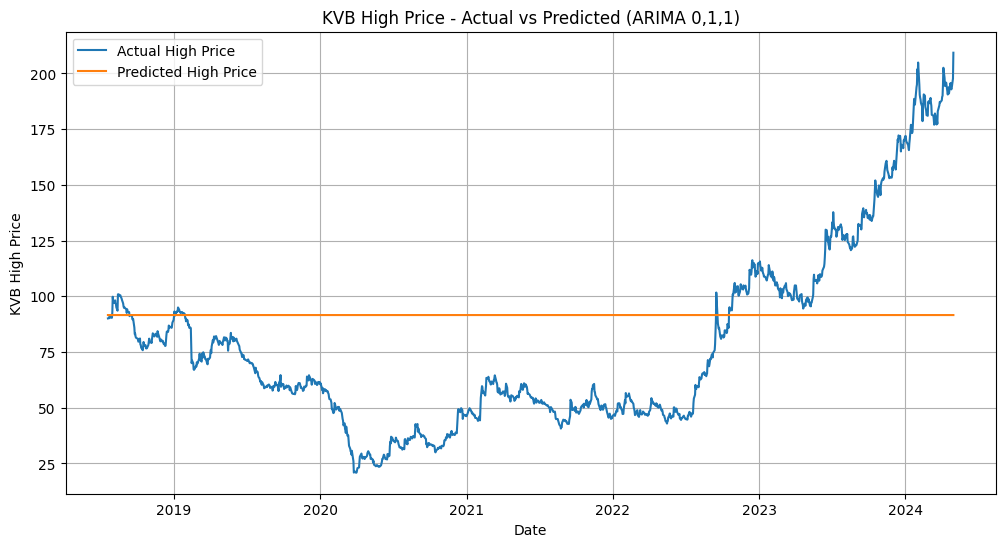

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(test.index, test.values, label='Actual High Price')
plt.plot(test.index, pred_011, label='Predicted High Price')

plt.xlabel('Date')
plt.ylabel('KVB High Price')
plt.title('KVB High Price - Actual vs Predicted (ARIMA 0,1,1)')
plt.legend()
plt.grid(True)

plt.show()

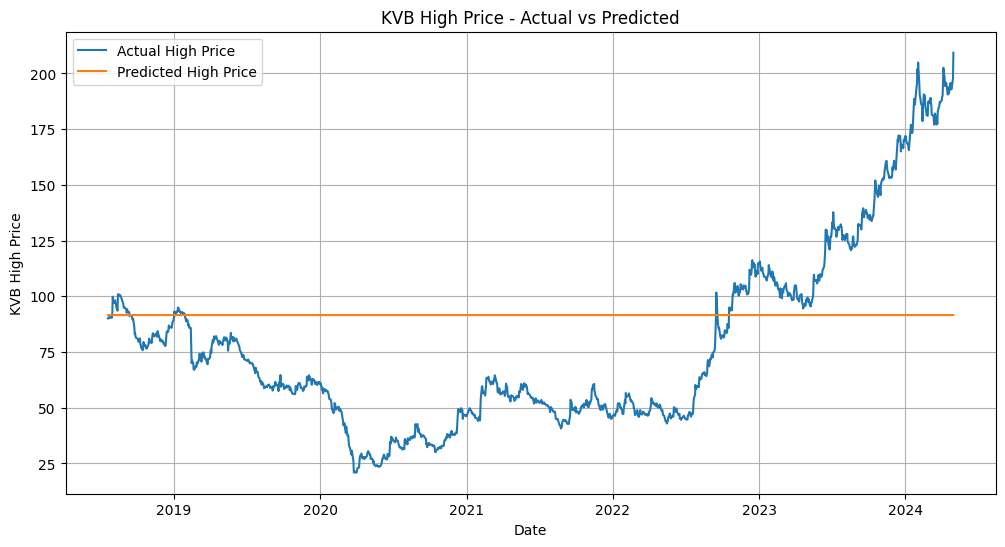

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(test.index, test.values, label='Actual High Price')
plt.plot(test.index, pred_011, label='Predicted High Price')

plt.xlabel('Date')
plt.ylabel('KVB High Price')
plt.title('KVB High Price - Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# ARIMA(0,1,1) - Next 10 Days Forecast

from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Full data-வை பயன்படுத்தி model உருவாக்குதல்
full_data = price_series.to_numpy()

model_future = ARIMA(full_data, order=(0, 1, 1))
model_future_fit = model_future.fit()

# அடுத்த 10 observations forecast
future_10 = model_future_fit.forecast(steps=10)

print("Next 10 Forecasted KVB High Prices:")
print(future_10)

Next 10 Forecasted KVB High Prices:
[205.51921248 205.51921248 205.51921248 205.51921248 205.51921248
 205.51921248 205.51921248 205.51921248 205.51921248 205.51921248]
